## PCA Example

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset from census.csv
df = pd.read_csv('census.csv')

# include only state_county_fips and fields starting with b_
df = df[['state_county_fips'] + [col for col in df.columns if col.startswith('b_')]]

# drop any NA
df = df.dropna()

df

,state_county_fips,b_pct_totalchildren_in_femaleonlyhouseholds,b_pct_totalchildrent_in_femalehouseholds_inlaborforce,b_pct_womenworkingparttime,b_pct_women15to50_withbirth12m,b_pct_totalchildren_per_women15to50,b_pct_education_hsplus,b_pct_education_less_than_hs,b_householdincome_clipped,b_householdincome_scaled,...,b_pct_owner_occupied_housing,b_pct_employment_16plus_whitecollar,b_pct_employment_over16,b_pct_employment_inlaborforce,b_pct_employment_primeage,b_pct_unemployment_over16,b_pct_unemployment_inlaborforce,b_pct_unemployment_primeage,b_pct_housing_vacant,b_pct_acctandauditfemale
0,1001,0.141106,0.132422,0.222087,0.043349,0.827708,0.902789,0.097211,69841.0,0.276002,...,0.749101,0.601016,0.985518,0.974584,0.939896,0.014482,0.025416,0.060104,0.089281,0.450000
1,1003,0.160412,0.157060,0.270118,0.039538,0.876872,0.917314,0.082686,75019.0,0.565939,...,0.775353,0.606959,0.981466,0.968057,0.947181,0.018534,0.031943,0.052819,0.263590,0.808000
4,1009,0.187517,0.185008,0.257809,0.040423,0.902069,0.826962,0.173038,61096.0,-0.213665,...,0.795058,0.593655,0.966532,0.941648,0.986610,0.033468,0.058352,0.013390,0.113580,0.949367
7,1015,0.318090,0.272553,0.284495,0.050433,0.753141,0.860862,0.139138,55826.0,-0.508753,...,0.703867,0.569598,0.964381,0.935620,0.870049,0.035619,0.064380,0.129951,0.152916,0.609375
15,1031,0.240913,0.195520,0.263406,0.072479,0.941902,0.860232,0.139768,64672.0,-0.013431,...,0.692330,0.569778,0.976670,0.956533,1.015048,0.023330,0.043467,-0.015048,0.145047,0.684211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3208,72127,0.584515,0.395639,0.311214,0.026763,0.593688,0.855067,0.144933,26981.0,-2.123898,...,0.534761,0.594576,0.924861,0.855462,0.905893,0.075139,0.144538,0.094107,0.234266,0.554156
3212,72135,0.388120,0.317127,0.271982,0.016569,0.560852,0.853756,0.146244,33349.0,-1.767328,...,0.820475,0.572100,0.957546,0.918432,0.828268,0.042454,0.081568,0.171732,0.137199,0.000000
3213,72137,0.511242,0.365655,0.287369,0.042532,0.534474,0.841106,0.158894,29648.0,-1.974562,...,0.709707,0.565750,0.950889,0.907434,0.984737,0.049111,0.092566,0.015263,0.177949,0.659574
3214,72139,0.303819,0.294923,0.278286,0.022218,0.560993,0.872462,0.127538,38773.0,-1.463617,...,0.743198,0.566458,0.960078,0.927924,1.063798,0.039922,0.072076,-0.063798,0.125606,0.645161


In [8]:

df_scaled = df.drop(columns=['state_county_fips'])  
X = df_scaled.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [11]:

# Show how the principal component scores map back into the original variables
print("\nPrincipal component scores (projections):")
print(X_pca)

# Display loadings - how each variable aligns with each component
feature_names = df_scaled.columns
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

print("\n\nLoadings - Alignment of Variables with Principal Components:")
print("(Shows how strongly each variable contributes to each PC)")
print(loadings_df)

print("\n\nVariable Contributions (sorted by absolute value):")
print("\nPC1 - Top contributors:")
print(loadings_df['PC1'].abs().sort_values(ascending=False))
print("\nPC2 - Top contributors:")
print(loadings_df['PC2'].abs().sort_values(ascending=False))


Principal component scores (projections):
[[-2.2494115   1.78060801]
 [-2.29244099  2.3162883 ]
 [ 1.87018667  2.22096928]
 ...
 [ 9.65212072 -0.15658402]
 [ 5.76213027  0.12776412]
 [12.8489791   0.80236942]]


Loadings - Alignment of Variables with Principal Components:
(Shows how strongly each variable contributes to each PC)
                                                         PC1       PC2
b_pct_totalchildren_in_femaleonlyhouseholds         0.269605 -0.084429
b_pct_totalchildrent_in_femalehouseholds_inlabo...  0.246876 -0.118984
b_pct_womenworkingparttime                         -0.013581  0.006791
b_pct_women15to50_withbirth12m                     -0.006426  0.111424
b_pct_totalchildren_per_women15to50                -0.081382  0.191307
b_pct_education_hsplus                             -0.230129 -0.088724
b_pct_education_less_than_hs                        0.230129  0.088724
b_householdincome_clipped                          -0.242197 -0.216677
b_householdincome_scaled     

#### Add PCA results back to a DataFrame

We can now use the PCA results to do further analysis or visualization.


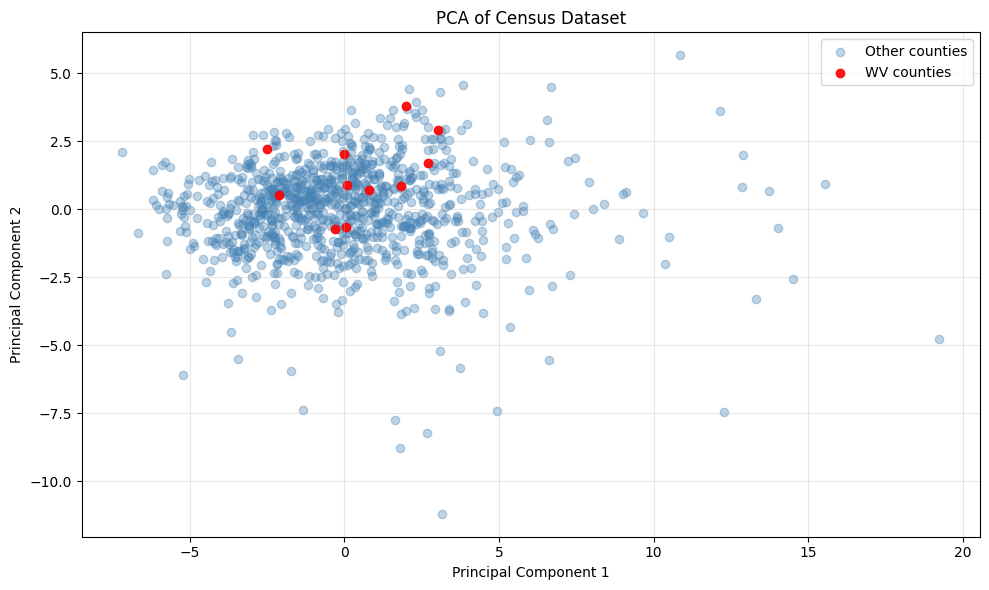

In [14]:
df_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

df_with_pca = pd.concat([df.reset_index(drop=True), df_pca], axis=1)

# Plot map of counties based on PC1 and PC2
import matplotlib.pyplot as plt

# West Virginia state FIPS code is 54
county_fips = df_with_pca['state_county_fips'].astype(str).str.zfill(5)
is_wv = county_fips.str.startswith('54')

plt.figure(figsize=(10, 6))
plt.scatter(
    df_with_pca.loc[~is_wv, 'PC1'],
    df_with_pca.loc[~is_wv, 'PC2'],
    alpha=0.35,
    c='steelblue',
    label='Other counties'
)
plt.scatter(
    df_with_pca.loc[is_wv, 'PC1'],
    df_with_pca.loc[is_wv, 'PC2'],
    alpha=0.9,
    c='red',
    label='WV counties'
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Census Dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
